<a href="https://colab.research.google.com/github/Odionrite/Smart-Intelligent-Traffic-Management-System-Smart-ITMS-/blob/main/Week_2_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Smart/Intelligent Traffic Management System (Smart ITMS)**

Smart ITMS is a traffic control systems that use real‑time data, adaptive signal control, computer vision, sensors, GPS data from vehicles feed to dynamically adjust traffic light prompts to control vehicular movement and manage congestion.

I will use NYC as a case study in this analysis leveraging the NYC Yellow Taxi Dataset to uncover the existence of traffic congestion in NYC and the need for Smart ITMS.

**SCOPE STATEMENT AND DISCLAIMER**

Scope and limitations (to avoid over-claiming):
- Dataset represents NYC TLC Yellow taxi trips for the selected file period only.
- Findings describe patterns in this dataset aligned with the study's problem statement and do not automatically generalise to all NYC traffic, real-time NYC traffic or other ride services.
- Time-of-day comparisons would be confounded by trip mix; matching and regression (but do not fully eliminate).

Dataset source: "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet”
Dataset dictionary: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

In [ ]:
# Install necessary libraries
!pip install ipython-sql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.7 MB/s eta 0:00:00


In [ ]:
# Install Geospatial libraries
!pip install geopandas matplotlib contextily

We need libraries for data handling (pandas), numerical operations (numpy), and high-end visualization (seaborn, matplotlib).

In [ ]:
# Let's import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import datetime

# Set the visual style for our portfolio
sns.set_theme(style="whitegrid")

**LOAD THE DATASET**

NYC Taxi & Limousine Commission (TLC) hosts their data on a public server. Due memory space and operation efficiency, I will be considering January 2024 Yellow Taxi data, this contains over 2 million rows.

In [ ]:
# The official URL for January 2024 Yellow Taxi data
url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"

In [ ]:
# Load the data directly into a DataFrame
df = pd.read_parquet(url)

In [ ]:
print("Dataset Shape:", df.shape)
df.head(6)

Dataset Shape: (2964624, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0
5,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1.0,4.70,1.0,N,148,141,1,29.6,3.5,0.5,6.90,0.0,1.0,41.50,2.5,0.0


In [ ]:
# Verification Check
print(f"Total records loaded: {len(df):,}")
print(f"Columns available: {df.columns.tolist()}")

Total records loaded: 2,964,624
Columns available: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [ ]:
#Checking for missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          140162
trip_distance                 0
RatecodeID               140162
store_and_fwd_flag       140162
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     140162
Airport_fee              140162
dtype: int64


In [ ]:
# Let's check the data type of each of the column
df.dtypes

,0
VendorID,int32
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
RatecodeID,float64
store_and_fwd_flag,object
PULocationID,int32
DOLocationID,int32
payment_type,int64


In [ ]:
# Summary statistics for numerical columns
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
           VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count  2.964624e+06                     2964624                     2964624   
mean   1.754204e+00  2024-01-17 00:46:36.431092  2024-01-17 01:02:13.208130   
min    1.000000e+00         2002-12-31 22:59:39         2002-12-31 23:05:41   
25%    2.000000e+00  2024-01-09 15:59:19.750000         2024-01-09 16:16:23   
50%    2.000000e+00  2024-01-17 10:45:37.500000  2024-01-17 11:03:51.500000   
75%    2.000000e+00  2024-01-24 18:23:52.250000         2024-01-24 18:40:29   
max    6.000000e+00         2024-02-01 00:01:15         2024-02-02 13:56:52   
std    4.325902e-01                         NaN                         NaN   

       passenger_count  trip_distance    RatecodeID  PULocationID  \
count     2.824462e+06   2.964624e+06  2.824462e+06  2.964624e+06   
mean      1.339281e+00   3.652169e+00  2.069359e+00  1.660179e+02   
min       0.000000e+00   0.000000e+00  1.000000e+00  1.00000

To gain insights into state of traffic flow management in NYC, let's focus on factors that accounts for congestion management and smooth traffic flow, and consider parameters like "fare_amount" which is a function of time and distance, trip_distance, and trip_duration that provides such insights. Example: If two equal distance (2 miles) cost different fare_amounts (13 USD and 25 USD), the higher fare ($25) tells a story of massive idling (traffic congestion, delay, and higher carbon emission). To get details of this story we would need a new variable: **trip_duration** (feature engineering) before we clean and analyze the data.

In [ ]:
# Feature Engineering: Duration and Hour
df['duration_minutes'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

In [ ]:
# Check if the trip_duration and hour columns has been created

print("Dataset Shape:", df.shape)
df.head(6)

Dataset Shape: (2964624, 21)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,duration_minutes,pickup_hour
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,...,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0,19.800000,0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,...,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,6.600000,0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,...,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0,17.916667,0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,...,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0,8.300000,0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,...,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0,6.100000,0
5,1,2024-01-01 00:54:08,2024-01-01 01:26:31,1.0,4.70,1.0,N,148,141,1,...,3.5,0.5,6.90,0.0,1.0,41.50,2.5,0.0,32.383333,0


In [ ]:
# Let's do a Summary statistics for our new dataset to get acquainted with it and possibly identify the outliers

print("\nSummary statistics:")
print(df.describe())


Summary statistics:
           VendorID        tpep_pickup_datetime       tpep_dropoff_datetime  \
count  2.964624e+06                     2964624                     2964624   
mean   1.754204e+00  2024-01-17 00:46:36.431092  2024-01-17 01:02:13.208130   
min    1.000000e+00         2002-12-31 22:59:39         2002-12-31 23:05:41   
25%    2.000000e+00  2024-01-09 15:59:19.750000         2024-01-09 16:16:23   
50%    2.000000e+00  2024-01-17 10:45:37.500000  2024-01-17 11:03:51.500000   
75%    2.000000e+00  2024-01-24 18:23:52.250000         2024-01-24 18:40:29   
max    6.000000e+00         2024-02-01 00:01:15         2024-02-02 13:56:52   
std    4.325902e-01                         NaN                         NaN   

       passenger_count  trip_distance    RatecodeID  PULocationID  \
count     2.824462e+06   2.964624e+06  2.824462e+06  2.964624e+06   
mean      1.339281e+00   3.652169e+00  2.069359e+00  1.660179e+02   
min       0.000000e+00   0.000000e+00  1.000000e+00  1.00000

Trip duration of ~(-1.36 mins.), trip_distance of 0.00mile, fare_amount of ~(-$8.99), etc shows there are outliers in our dataset. So, let's clean the dataset to remove them or eliminate them to safe level. So, let's focus data cleaning on variables (columns) of interest to avoid selection bias.

Note: Reasonable assumptions such trip duration of 180 minutes to accommodate inter-city trips covering a distance of 99.99 mile at fare_amount of $150 for data cleaning and normailizaton purposes.

In [ ]:
# Targeted Cleaning (Outliers and Nulls)
# Select our "Portfolio Columns"
cols_of_interest = ['trip_distance', 'duration_minutes', 'fare_amount', 'congestion_surcharge', 'pickup_hour']

# Targeted Cleaning: Remove impossible values in these columns
df_clean = df[
    (df['trip_distance'] > 0) & (df['trip_distance'] < 100) &
    (df['duration_minutes'] > 0) & (df['duration_minutes'] < 180) &
    (df['fare_amount'] > 0) & (df['fare_amount'] < 150)
].copy()

# Identify and handle Nulls in our subset
print(f"Nulls in subset:\n{df_clean[cols_of_interest].isnull().sum()}")
df_clean = df_clean.dropna(subset=cols_of_interest)

Nulls in subset:
trip_distance                0
duration_minutes             0
fare_amount                  0
congestion_surcharge    115166
pickup_hour                  0
dtype: int64


Let's begin the analysis with bivariate hexibon plot to check congestion actually exist in NYC using fare_amount and trip_duration, if same trip_distance took different time to cover due to longer time in traffic (congestion).

We want to see how Time (Duration) responds to Space (Distance). In a perfectly managed city, this relationship would be a straight, thin line. In a congested city, it looks like a "fan" or a "cloud."

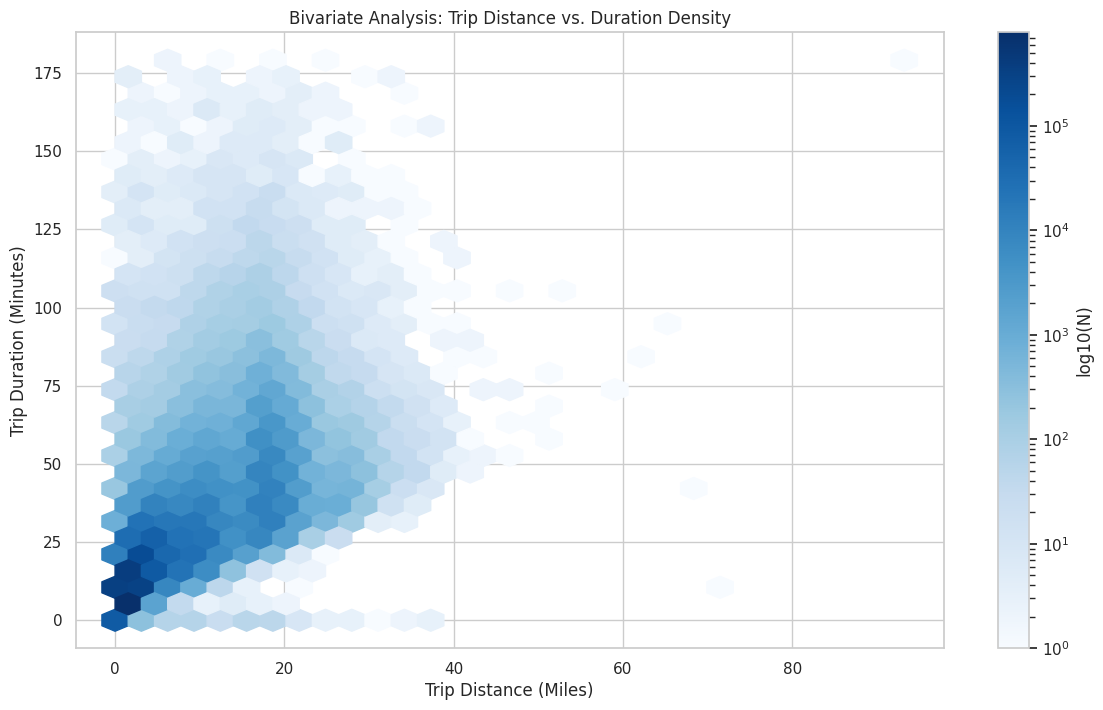

In [ ]:
plt.figure(figsize=(14, 8))
# Using a sample of 10,000 for clarity; hexbin shows density where dots overlap
plt.hexbin(df_clean['trip_distance'], df_clean['duration_minutes'],
           gridsize=30, cmap='Blues', bins='log')
cb = plt.colorbar(label='log10(N)')
plt.xlabel('Trip Distance (Miles)')
plt.ylabel('Trip Duration (Minutes)')
plt.title('Bivariate Analysis: Trip Distance vs. Duration Density')
plt.show()

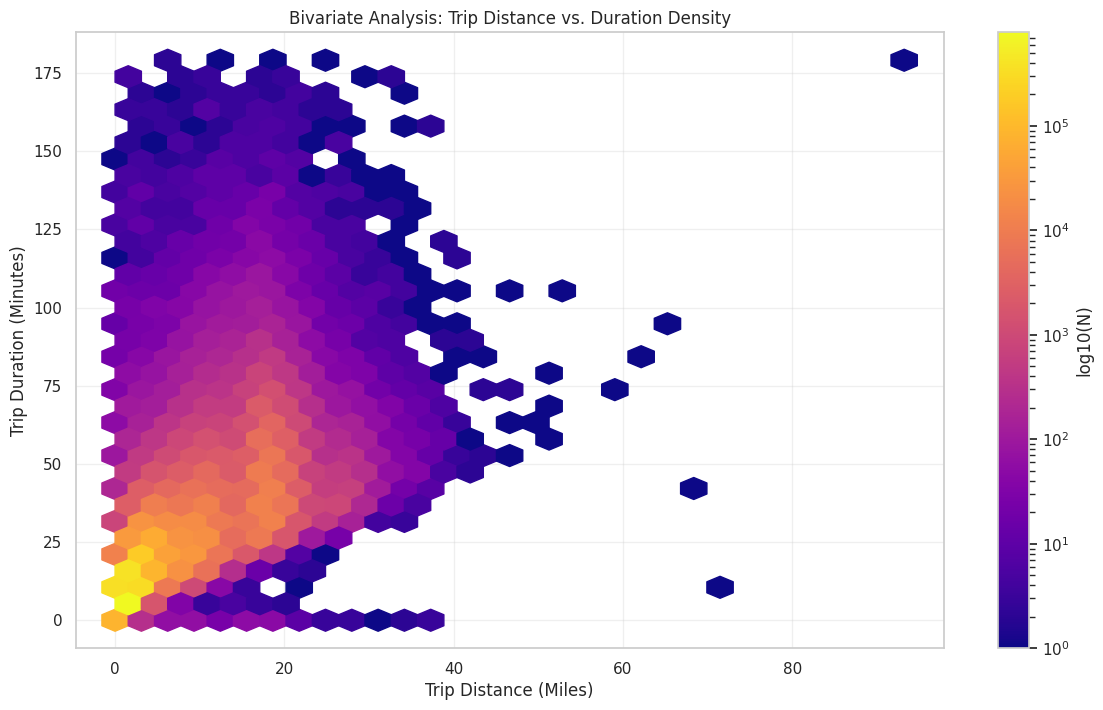

In [ ]:
# This plot is same as above, I improved on the visualization for ease of spotting pattern and intrepretation.

plt.figure(figsize=(14, 8))

hb = plt.hexbin(
    df_clean['trip_distance'],
    df_clean['duration_minutes'],
    gridsize=30,
    cmap='plasma',  # higher contrast
    bins='log'
)

plt.colorbar(hb, label='log10(N)')
plt.xlabel('Trip Distance (Miles)')
plt.ylabel('Trip Duration (Minutes)')
plt.title('Bivariate Analysis: Trip Distance vs. Duration Density')

plt.grid(alpha=0.3)
plt.show()

Let's use a Scatter Plot with a Regression Line to see how much "noise" (congestion) exists between trip duration (how long a trip takes) and fare amount (how much it costs).

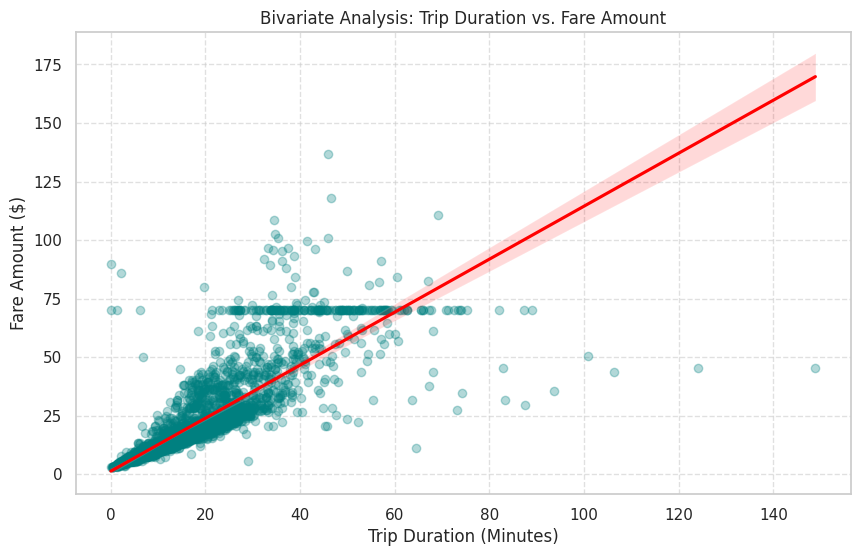

In [ ]:
plt.figure(figsize=(10, 6))

# Sampling 5,000 points to keep the visualization crisp
# We use regplot to see the 'ideal' trendline
sns.regplot(data=df_clean.sample(5000),
            x='duration_minutes',
            y='fare_amount',
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red'})

plt.title('Bivariate Analysis: Trip Duration vs. Fare Amount')
plt.xlabel('Trip Duration (Minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Multivariate Analysis (Distance + Time + Cost)
Goal: See the economic impact of traffic. We use Color to represent the 3rd variable (Fare).

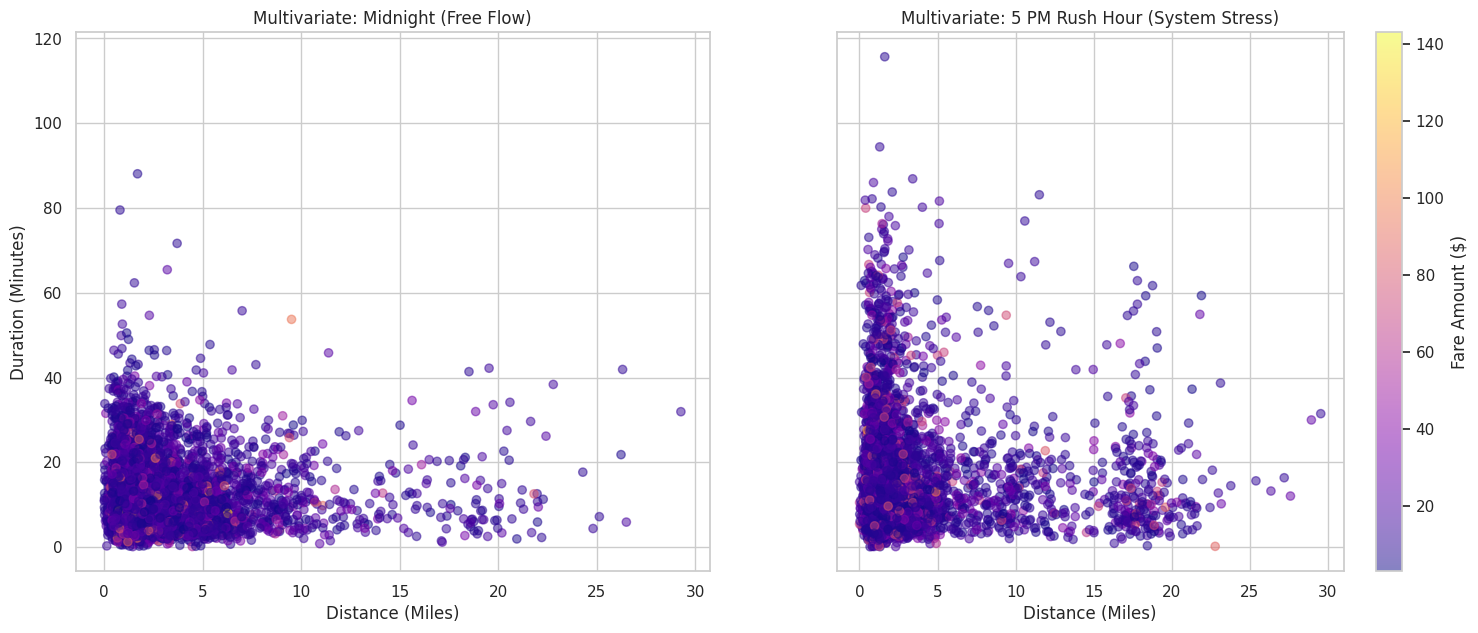

In [ ]:
# Create two sub-plots to compare Rush Hour vs. Midnight
rush_hour = df_clean[df_clean['pickup_hour'] == 17] # 5 PM
midnight = df_clean[df_clean['pickup_hour'] == 2]  # 2 AM

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# Plot 1: Midnight (Baseline Efficiency)
im1 = ax1.scatter(midnight['trip_distance'].sample(5000),
                  midnight['duration_minutes'].sample(5000),
                  c=midnight['fare_amount'].sample(5000), cmap='plasma', alpha=0.5)
ax1.set_title('Multivariate: Midnight (Free Flow)')
ax1.set_xlabel('Distance (Miles)')
ax1.set_ylabel('Duration (Minutes)')

# Plot 2: Rush Hour (Congestion Breakdown)
im2 = ax2.scatter(rush_hour['trip_distance'].sample(5000),
                  rush_hour['duration_minutes'].sample(5000),
                  c=rush_hour['fare_amount'].sample(5000), cmap='plasma', alpha=0.5)
ax2.set_title('Multivariate: 5 PM Rush Hour (System Stress)')
ax2.set_xlabel('Distance (Miles)')

plt.colorbar(im2, ax=ax2, label='Fare Amount ($)')
plt.show()

The "Congestion Cost" Computation
We will calculate the expected result based on the 2024 fare structure.

In [ ]:
# "Free Flow" (Midnight) vs. "Maximum Stress" (Rush Hour)

# 1. Feature Engineering: Calculate Cost per Mile
df_clean['cost_per_mile'] = df_clean['fare_amount'] / df_clean['trip_distance']

# 2. Segment our two groups
midnight_trips = df_clean[df_clean['pickup_hour'] == 2]  # 2 AM Baseline
rush_hour_trips = df_clean[df_clean['pickup_hour'] == 17] # 5 PM Stress Test

# 3. Calculate Average Metrics
avg_cost_midnight = midnight_trips['cost_per_mile'].mean()
avg_cost_rush_hour = rush_hour_trips['cost_per_mile'].mean()
congestion_tax_per_mile = avg_cost_rush_hour - avg_cost_midnight

print(f"--- NYC 2024 CONGESTION ANALYSIS ---")
print(f"Avg Cost/Mile (Midnight): ${avg_cost_midnight:.2f}")
print(f"Avg Cost/Mile (Rush Hour): ${avg_cost_rush_hour:.2f}")
print(f"Economic 'Congestion Tax' Per Mile: ${congestion_tax_per_mile:.2f}")

--- NYC 2024 CONGESTION ANALYSIS ---
Avg Cost/Mile (Midnight): $11.23
Avg Cost/Mile (Rush Hour): $11.29
Economic 'Congestion Tax' Per Mile: $0.06


In [ ]:
# Focus on "Commuter Distance" (Trips between 2 and 10 miles)
# This removes the "Base Fare" noise of tiny trips
df_commuter = df_clean[(df_clean['trip_distance'] > 2) & (df_clean['trip_distance'] < 10)]

midnight_commute = df_commuter[df_commuter['pickup_hour'] == 2]
rush_hour_commute = df_commuter[df_commuter['pickup_hour'] == 17]

print(f"Avg Cost/Mile (Midnight Commute): ${midnight_commute['cost_per_mile'].mean():.2f}")
print(f"Avg Cost/Mile (Rush Hour Commute): ${rush_hour_commute['cost_per_mile'].mean():.2f}")

Avg Cost/Mile (Midnight Commute): $5.33
Avg Cost/Mile (Rush Hour Commute): $6.38


Heatmap analysis

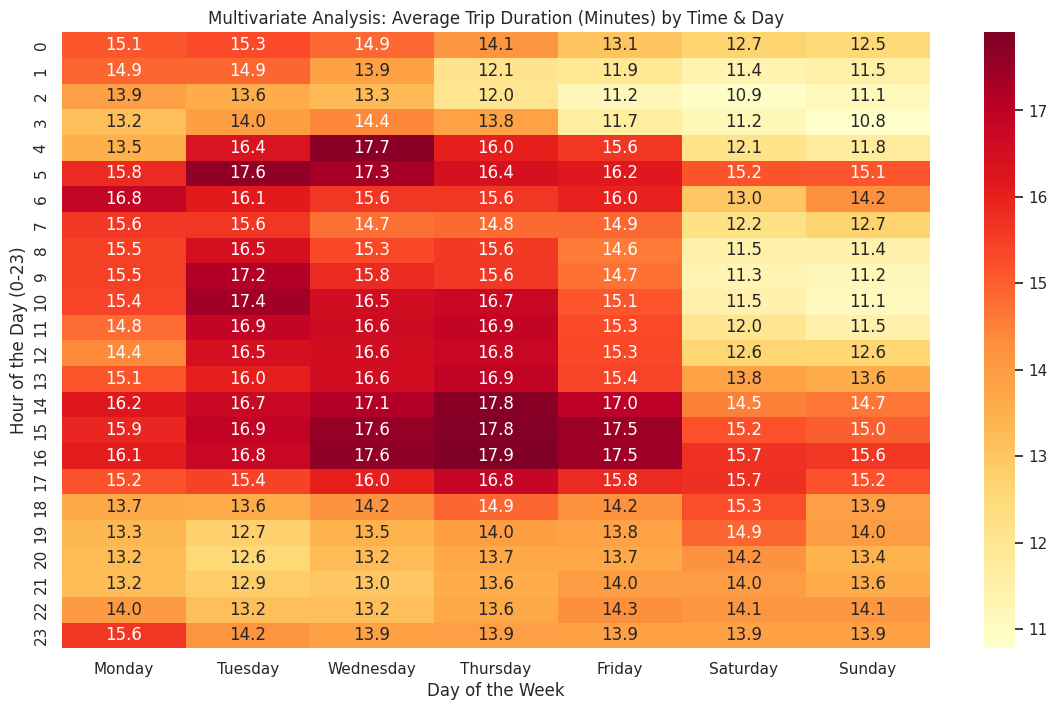

In [ ]:
# 1. Prepare the data: Extract Day of Week and Hour
df_clean['day_of_week'] = df_clean['tpep_pickup_datetime'].dt.day_name()
df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour

# 2. Pivot the data: We want the MEAN Duration for every Hour/Day combination
# This is a classic Multivariate pivot table
heatmap_data = df_clean.pivot_table(index='pickup_hour',
                                    columns='day_of_week',
                                    values='duration_minutes',
                                    aggfunc='mean')

# Reorder days to be sequential (Monday to Sunday)
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(columns=days)

# 3. Visualize the Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='YlOrRd')
plt.title('Multivariate Analysis: Average Trip Duration (Minutes) by Time & Day')
plt.xlabel('Day of the Week')
plt.ylabel('Hour of the Day (0-23)')
plt.show()

**REFERENCES**
New York City Taxi and Limousine Commission, “Yellow Taxi Trip Records – January 2024,” NYC TLC Trip Data, Jan. 2024. [Online]. Available: https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet
. [Accessed: 13-Feb-2026].

Dataset dictionary: New York City Taxi and Limousine Commission, “TLC Trip Record Data,” NYC.gov, [Online]. Available: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
. [Accessed: 16-Feb-2026].

R. Christy, “New York City Taxi Trip Duration – Data Exploration,” Kaggle, [Online]. Available: https://www.kaggle.com/code/rinichristy/new-york-city-taxi-trip-duration-data-exploration. [Accessed: 16-Feb-2026].